In [84]:
import PIL.PngImagePlugin
import numpy as np
import pandas as pd
from PIL import Image
from pandas.core.interchange.dataframe_protocol import DataFrame

In [85]:
import importlib
from datasets import load_dataset

ds = load_dataset("ylecun/mnist")

In [86]:
train = ds['train']
test = ds['test']
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)

In [87]:
class Layer:
    def __init__(self,neurons,weights,biases):
        self.neurons = neurons
        self.weights = weights
        self.biases = biases

In [88]:
train_item = train_df.iloc[0]
image = np.array(train_item['image']) / 255.0
neurons = image.flatten()
initial_layer = Layer(np.array(neurons), None, None)
initial_layer.neurons

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [89]:
hidden_layer_size = 128
weights_1 = np.random.randn(784,hidden_layer_size) * 0.01
biases_1 = np.zeros(hidden_layer_size)

h_layer = Layer(None, weights_1, biases_1)


In [90]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

hidden_layer_activations = initial_layer.neurons @ h_layer.weights + h_layer.biases
h_layer.neurons = sigmoid(hidden_layer_activations)

In [91]:
output_layer_size = 10

weights_2 = np.random.randn(hidden_layer_size, output_layer_size) * 0.01
biases_2 = np.zeros(output_layer_size)

output_layer = Layer(None,weights_2,biases_2)
output_layer_activations = h_layer.neurons @ output_layer.weights + output_layer.biases
output_layer.neurons = softmax(output_layer_activations)


In [92]:
print(output_layer.neurons)
print(np.sum(output_layer.neurons))

[0.09492741 0.10081009 0.10876129 0.0914363  0.10059122 0.0992977
 0.10082785 0.10302294 0.09941166 0.10091354]
1.0


In [93]:
true_label = train_item['label']

def cost(pred,true):
    return -np.log(pred[true] + 1e-9)

loss = cost(output_layer.neurons,true_label)
print(loss)

2.3096328464423435


dC/dW2 = dC/dPred * dPred/d(output_layer_activations) * d(output_layer_activations)/dW2
 (pred - true) * d(output_layer_activations) / dW2
 d(output_layer_activations) / dW2 = hidden_layer.neurons

dC/dW2 = (pred - true) × hidden_layer.neurons

In [95]:
true_vector = np.zeros(10)
true_vector[true_label] = 1

dZ2 = output_layer.neurons - true_vector
dW2 = np.outer(h_layer.neurons, dZ2)
db2 = dZ2

dA1 = dZ2 @ output_layer.weights.T
dZ1 = dA1 * h_layer.neurons * (1 - h_layer.neurons)
dW1 = np.outer(initial_layer.neurons, dZ1)
db1 = dZ1

In [96]:
lr = 0.1

h_layer.weights -= lr * dW1
h_layer.biases  -= lr * db1
output_layer.weights -= lr * dW2
output_layer.biases  -= lr * db2

In [97]:
z1_new = initial_layer.neurons @ h_layer.weights + h_layer.biases
a1_new = sigmoid(z1_new)
z2_new = a1_new @ output_layer.weights + output_layer.biases
pred_new = softmax(z2_new)

new_loss = cost(pred_new, true_label)
print("Old loss:", loss)
print("New loss:", new_loss)

Old loss: 2.3096328464423435
New loss: 0.28977885573389905


In [121]:
def get_init_layer(img):
    a = np.asarray(img).flatten() / 255.0
    i_layer = Layer(np.array(a),None,None)
    return i_layer

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def forward(i_layer):
    z1 = i_layer.neurons @ h_layer.weights + h_layer.biases
    h_layer.neurons = sigmoid(z1)
    z2 = h_layer.neurons @ output_layer.weights + output_layer.biases
    output_layer.neurons = softmax(z2)
    return i_layer

def backtrack(init_layer,true_label,learning_rate = 0.1):
    true_vector = np.zeros(10)
    true_vector[true_label] = 1

    dZ2 = output_layer.neurons - true_vector
    dW2 = np.outer(h_layer.neurons, dZ2)
    db2 = dZ2

    dA1 = dZ2 @ output_layer.weights.T
    dZ1 = dA1 * h_layer.neurons * (1 - h_layer.neurons)
    dW1 = np.outer(init_layer.neurons, dZ1)
    db1 = dZ1

    h_layer.weights -= learning_rate * dW1
    h_layer.biases  -= learning_rate * db1
    output_layer.weights -= learning_rate * dW2
    output_layer.biases  -= learning_rate * db2


def train(learning_rate=0.1,shuffle = True):
    df = train_df.sample(frac=1).reset_index(drop=True) if shuffle else train_df
    n = len(df)
    total_loss = 0
    for i in range(n):
        image = df.iloc[i]['image']
        label = df.iloc[i]['label']
        i_layer = get_init_layer(image)
        i_layer = forward(i_layer)
        loss = -np.log(output_layer.neurons[label] + 1e-9)
        total_loss += loss
        backtrack(i_layer, label, learning_rate)
        if i % 5000 == 0:
            print(f"Example {i}/{n}, loss: {loss:.4f}")
    avg_loss = total_loss / n
    print(f"Average loss: {avg_loss:.4f}")
    return avg_loss


In [122]:
W1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros(128)
W2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros(10)

h_layer = Layer(neurons=None, weights=W1, biases=b1)
output_layer = Layer(neurons=None, weights=W2, biases=b2)

In [123]:
num_epochs = 3
for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1}/{num_epochs} ---")
    train(learning_rate=0.1)

--- Epoch 1/3 ---
Example 0/60000, loss: 2.3640
Example 5000/60000, loss: 0.0204
Example 10000/60000, loss: 0.0024
Example 15000/60000, loss: 0.6164
Example 20000/60000, loss: 0.0282
Example 25000/60000, loss: 0.0004
Example 30000/60000, loss: 0.0153
Example 35000/60000, loss: 0.0001
Example 40000/60000, loss: 0.0013
Example 45000/60000, loss: 0.0024
Example 50000/60000, loss: 0.0017
Example 55000/60000, loss: 0.0226
Average loss: 0.2492
--- Epoch 2/3 ---
Example 0/60000, loss: 0.0000
Example 5000/60000, loss: 0.0026
Example 10000/60000, loss: 0.0003
Example 15000/60000, loss: 0.0038
Example 20000/60000, loss: 0.0000
Example 25000/60000, loss: 0.0007
Example 30000/60000, loss: 0.0004
Example 35000/60000, loss: 0.0123
Example 40000/60000, loss: 0.0031
Example 45000/60000, loss: 2.4131
Example 50000/60000, loss: 0.0000
Example 55000/60000, loss: 0.0001
Average loss: 0.1189
--- Epoch 3/3 ---
Example 0/60000, loss: 0.0000
Example 5000/60000, loss: 0.0000
Example 10000/60000, loss: 0.0060
E

In [137]:
def predict(image):
    i_layer = get_init_layer(image)
    forward(i_layer)
    return output_layer.neurons
correct_predictions = 0
incorrect_images = []
for i in range(test_df.shape[0]):
    image = test_df.iloc[i]['image']
    label = test_df.iloc[i]['label']
    probs = predict(image)
    predicted_label = np.argmax(probs)
    if predicted_label == label:
        correct_predictions +=1
    else:
        incorrect_images.append((image,label,predicted_label))


print("Correct perdictions:", correct_predictions)
print("Correct perdictions %:", correct_predictions/test_df.shape[0] * 100)

Correct perdictions: 9643
Correct perdictions %: 96.43


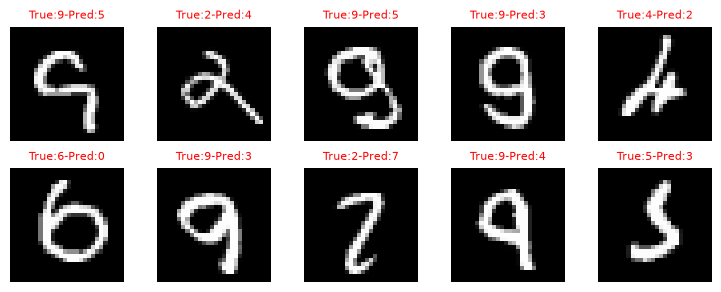

In [136]:
import matplotlib.pyplot as plt
import math

n = 10
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))

for i in range(rows * cols):
    ax = axes[i // cols, i % cols]
    if i < n:
        image, true_label, pred_label = incorrect_images[i]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"True:{true_label}-Pred:{pred_label}", color='red', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()